## Real Market Frontier Study (Fractional VQE Client)

This notebook uses **real market data** to demonstrate the package's **fractional lambda-sweep** workflow rather than a single optimization run.

### Focus

This example is about how allocations change across risk-aversion values and how those allocations map to an efficient frontier.

### Pipeline

1. Download adjusted prices for a diversified ticker set.
2. Estimate annualized expected returns $\mu$ and covariance $\Sigma$.
3. Run `fractional_lambda_sweep(...)` across a grid of $\lambda$ values.
4. Build a frontier with `fractional_frontier_from_allocs(...)`.
5. Visualize both the allocation sweep and the resulting risk-return curve.

### Requirements

```bash
pip install "vqe-portfolio[data]"
```


In [1]:
from __future__ import annotations

import matplotlib.pyplot as plt
import numpy as np

from vqe_portfolio import get_stock_data, fractional_lambda_sweep
from vqe_portfolio.frontier import fractional_frontier_from_allocs
from vqe_portfolio.plotting import (
    bar_allocations,
    plot_frontier,
    plot_lambda_sweep_bars,
)
from vqe_portfolio.types import FractionalVQEConfig, LambdaSweepConfig
from vqe_portfolio.utils import resolve_notebook_outdir, set_global_seed

SEED = 0
set_global_seed(SEED)

OUTDIR = resolve_notebook_outdir()

## Data configuration

In [2]:
tickers = ["MSFT", "JPM", "XOM", "JNJ", "COST"]
start = "2024-01-01"
end = "2025-01-01"

mu_s, Sigma_df, prices = get_stock_data(
    tickers,
    start=start,
    end=end,
    auto_adjust=True,
    use_log=True,
    shrink="lw",
    scale="none",
)

mu = np.array(mu_s.loc[tickers].values, dtype=float)
Sigma = np.array(Sigma_df.loc[tickers, tickers].values, dtype=float)

print("Tickers:", tickers)
print("Annualized mu:")
for t, m in zip(tickers, mu):
    print(f"  {t}: {float(m): .6f}")
print("\nSigma (annualized) shape:", Sigma.shape)
print("Prices rows:", prices.shape[0])

Tickers: ['MSFT', 'JPM', 'XOM', 'JNJ', 'COST']
Annualized mu:
  MSFT:  0.131252
  JPM:  0.344144
  XOM:  0.080629
  JNJ: -0.067564
  COST:  0.337450

Sigma (annualized) shape: (5, 5)
Prices rows: 261


## Run a fractional lambda sweep

In [3]:
cfg = FractionalVQEConfig(
    steps=80,
    stepsize=0.20,
    log_every=10,
    shots=None,
    lam=1.0,
    seed=SEED,
    device="default.qubit",
)

sweep = LambdaSweepConfig(
    lambdas=[0.5, 1.0, 2.0, 4.0, 8.0],
    steps_per_lambda=50,
    stepsize=0.20,
    warm_start=True,
)

res = fractional_lambda_sweep(mu, Sigma, cfg, sweep)
allocs = np.array(res.allocs_by_lambda, dtype=float)

for lam, w in zip(res.lambdas, allocs):
    print(f"lambda={float(lam):.2f}")
    for t, wi in zip(tickers, w):
        print(f"  {t}: {float(wi):.4f}")
    print()

lambda=0.50
  MSFT: 0.0000
  JPM: 0.5001
  XOM: 0.0000
  JNJ: 0.0000
  COST: 0.4999

lambda=1.00
  MSFT: 0.0000
  JPM: 0.4506
  XOM: 0.0000
  JNJ: 0.0000
  COST: 0.5494

lambda=2.00
  MSFT: 0.0000
  JPM: 0.4269
  XOM: 0.0000
  JNJ: 0.0000
  COST: 0.5730

lambda=4.00
  MSFT: 0.0000
  JPM: 0.4156
  XOM: 0.0000
  JNJ: 0.0000
  COST: 0.5844

lambda=8.00
  MSFT: 0.0000
  JPM: 0.3760
  XOM: 0.0621
  JNJ: 0.0000
  COST: 0.5619



## Frontier construction

In [4]:
frontier = fractional_frontier_from_allocs(
    mu,
    Sigma,
    np.array(res.lambdas, dtype=float),
    allocs,
    sort_by="risk",
)

print("Frontier points (sorted by risk):")
for lam, risk, ret in zip(frontier.lambdas, frontier.risks, frontier.returns):
    print(f"  lambda={float(lam):.2f}  risk={float(risk):.6f}  return={float(ret):.6f}")

Frontier points (sorted by risk):
  lambda=8.00  risk=0.144192  return=0.324008
  lambda=4.00  risk=0.151739  return=0.340232
  lambda=2.00  risk=0.151828  return=0.340300
  lambda=1.00  risk=0.152215  return=0.340450
  lambda=0.50  risk=0.153889  return=0.340788


## Allocation sweep plot

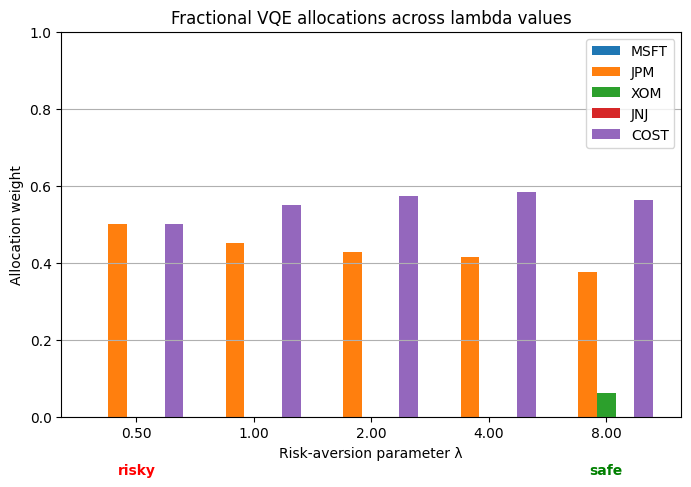

In [5]:
plot_lambda_sweep_bars(
    res.lambdas,
    allocs,
    asset_labels=tickers,
    ylabel="Allocation weight",
    title="Fractional VQE allocations across lambda values",
    outpath=OUTDIR / "Fractional_VQE_Lambda_Sweep_Real_Example_01.png",
)
plt.show()

## Efficient frontier plot

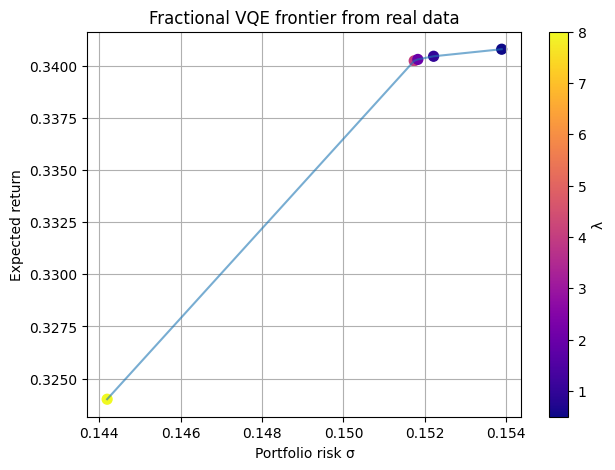

In [6]:
plot_frontier(
    frontier.risks,
    frontier.returns,
    frontier.lambdas,
    title="Fractional VQE frontier from real data",
    outpath=OUTDIR / "Fractional_VQE_Frontier_Real_Example_01.png",
)
plt.show()

## Highest-lambda allocation snapshot

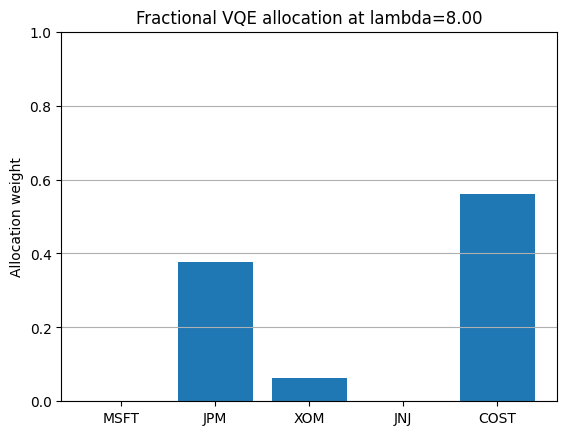

In [7]:
bar_allocations(
    tickers,
    allocs[-1],
    ylabel="Allocation weight",
    title=f"Fractional VQE allocation at lambda={float(res.lambdas[-1]):.2f}",
    ylim=(0.0, 1.0),
    outpath=OUTDIR / "Fractional_VQE_Final_Allocation_Real_Example_01.png",
)
plt.show()